# First attempts on the highway-env environment

In [5]:
import gymnasium as gym
from collections import deque
import highway_env
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from tqdm import tqdm
from stable_baselines3 import DQN as SB3_DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from shared_core_config import SHARED_CORE_ENV_ID, SHARED_CORE_CONFIG
import imageio
from IPython.display import Image

## Getting familiar with the environment

### First environment

In [6]:
def make_env(render_mode="rgb_array"):
    env = gym.make("highway-v0", render_mode=render_mode)
    env.unwrapped.configure(SHARED_CORE_CONFIG)
    env.reset()
    env = Monitor(env) 
    return env

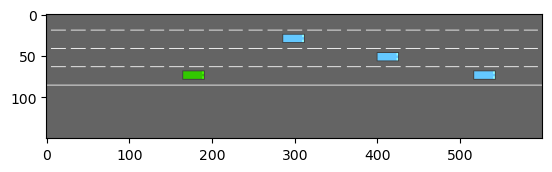

Observation space shape: (10, 5)
Action space: Discrete(5)


In [7]:
temp_env = make_env()
obs, info = temp_env.reset()

# Visualization
plt.imshow(temp_env.render())
plt.show()
print(f"Observation space shape: {temp_env.observation_space.shape}")
print(f"Action space: {temp_env.action_space}")

### Test with random actions

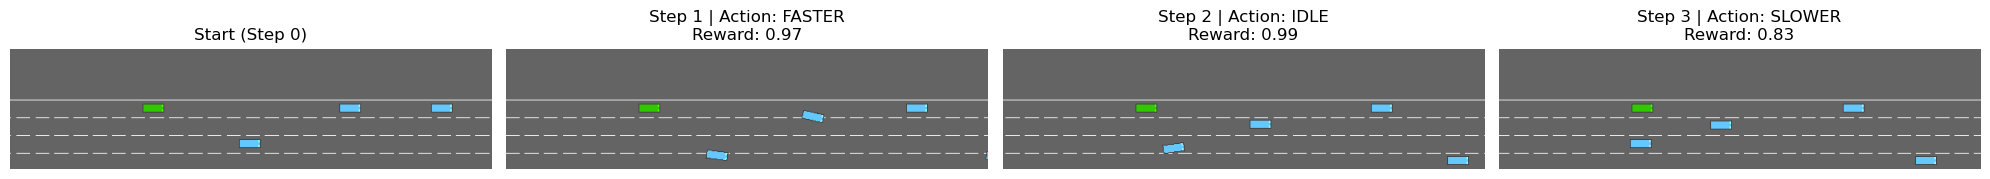

In [8]:
env = make_env(render_mode="rgb_array")

obs, info = env.reset()

# Plotting the start, and the result of 3 actions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot the starting state
axes[0].imshow(env.render())
axes[0].set_title("Start (Step 0)")
axes[0].axis('off')

action_names = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

for step in range(1, 4):
    # We pick a random action
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    # Plot
    axes[step].imshow(env.render())
    title = f"Step {step} | Action: {action_names[action]}\nReward: {reward:.2f}"
    axes[step].set_title(title)
    axes[step].axis('off')
    if terminated or truncated:
        print(f"Episode ended early at step {step}!")
        break
plt.tight_layout()
plt.show()

env.close()

## Defining useful functions

Evaluate an agent: computes the mean and standard deviations of the total rewards.

In [9]:
def evaluate_agent(agent, num_episodes=50, seeds=[3, 33, 333]):
    """
    Evaluates an agent on multiple seeds
    """
    print(f"Starting evaluation: {num_episodes} episodes per seed.")
    all_seed_results = []
    
    for seed in seeds:
        env = make_env() 
        episode_rewards = []
        for episode in tqdm(range(num_episodes), desc=f"Evaluating Seed {seed}"):
            obs, info = env.reset(seed=seed + episode)
            done = False
            total_reward = 0
            while not done:
                if hasattr(agent, "predict"):
                    # logic for Stable-Baselines3 model
                    action, _states = agent.predict(obs, deterministic=True)
                else:
                    # logic for DQN 
                    q_values = agent.get_q(obs)
                    action = np.argmax(q_values)
                obs, reward, terminated, truncated, info = env.step(action)
                total_reward += reward
                done = terminated or truncated   
            episode_rewards.append(total_reward)
        env.close()
        
        # Now that we have ran it for all episodes, we can compute the mean adn standard deviation
        # of the total rewards
        mean_reward = np.mean(episode_rewards)
        std_reward = np.std(episode_rewards)
        print(f"Seed {seed} | Mean Reward: {mean_reward:.2f} +/- {std_reward:.2f}\n")
        all_seed_results.append((seed, mean_reward, std_reward))
        
    return all_seed_results

Plot the reward and the loss curves

In [10]:
def plot_training_curves(episode_rewards, episode_losses):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Reward curve
    axes[0].plot(episode_rewards, alpha=0.6, color='blue')
    if len(episode_rewards) >= 20:
        rolling_avg = np.convolve(episode_rewards, np.ones(20)/20, mode='valid')
        axes[0].plot(range(19, len(episode_rewards)), rolling_avg, color='red', linewidth=2, label='20-ep Moving Avg')
    axes[0].set_title("Training curve: Episode rewards")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Total reward")
    axes[0].legend()

    # Loss curve
    axes[1].plot(episode_losses, color='orange', alpha=0.8)
    axes[1].set_title("Training curve: Mean loss per episode")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("MSE loss")

    plt.tight_layout()
plt.show()

Record and display a rollout

In [11]:
def record_display_rollout(agent, seed, name_dir=".", name_gif="agent_rollout"):
    env_record = make_env(render_mode="rgb_array")
    obs, info = env_record.reset(seed=seed)
    frames = []
    done = False
    step_count = 0
    print(f"Recording rollout")

    while not done:
        # Capture the visual frame
        frame = env_record.render()
        frames.append(frame)
        q_values = agent.get_q(obs)
        action = np.argmax(q_values)
        # Take the action
        obs, reward, terminated, truncated, info = env_record.step(action)
        done = terminated or truncated
        step_count += 1
    env_record.close()

    gif_path = f"{name_dir}/{name_gif}_seed{seed}.gif"
    imageio.mimsave(gif_path, frames, fps=15)
    print(f"Episode finished after {step_count} steps.")
    # Display the GIF
    return Image(open(gif_path, 'rb').read())

Train agent (custom agent, not SB3)

In [12]:
def train_agent(agent, env, n_episodes=500):
    """
    Trains the N agent and returns the trained agent and its training metrics
    """
    episode_rewards = []
    episode_losses = []

    for episode in tqdm(range(n_episodes), desc="Training agent"):
        state, _ = env.reset()
        done = False
        total_reward = 0
        ep_losses = []
        
        while not done:
            # Choose the action (random with probability epsilon)
            action = agent.get_action(state)
            # Take action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            # Now, we update the parameters by gradient descent and store the transitions in the buffer
            loss = agent.update(state, action, reward, terminated, next_state)
            state = next_state
            total_reward += reward
            if loss != np.inf:
                ep_losses.append(loss)
        # Store the total reward and losses for the learning curves
        episode_rewards.append(total_reward)
        if ep_losses:
            episode_losses.append(np.mean(ep_losses))

    return agent, episode_rewards, episode_losses

## Implementing models

### 1. Implement the Stable-Baselines3 baseline model

#### 1.1 - Train the SB3 baseline model

In [6]:
# env_sb3 = make_env()

# print("Initializing SB3 DQN")

#    model_sb3 = SB3_DQN(
#       policy="MlpPolicy", 
#        env=env_sb3, 
#        learning_rate=5e-4,
#        buffer_size=15000,
#        learning_starts=200,
#        batch_size=32,
#        gamma=0.8,
#        train_freq=1,
#        gradient_steps=1,
#        target_update_interval=50,
#        exploration_fraction=0.7,
#        verbose=1 
#    )

# print("Starting training")

# model_sb3.learn(total_timesteps=20000)
# model_sb3.save("dqn_sb3_highway")

# print("SB3 Baseline training complete and model saved")

#### 1.2 - Evaluate the SB3 baseline model

In [6]:
from stable_baselines3 import DQN as SB3_DQN

model_sb3 = SB3_DQN.load("dqn_sb3_highway")
sb3_results = evaluate_agent(model_sb3, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [05:44<00:00,  6.90s/it]


Seed 3 | Mean Reward: 10.57 +/- 5.77



Evaluating Seed 33: 100%|██████████| 50/50 [06:17<00:00,  7.55s/it]


Seed 33 | Mean Reward: 11.64 +/- 6.20



Evaluating Seed 333: 100%|██████████| 50/50 [05:19<00:00,  6.40s/it]

Seed 333 | Mean Reward: 9.90 +/- 4.88



### 2. Implement a Deep Q-Network (DQN)

#### 2.1 - Replay Buffer

In [13]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = [] # stores the transitions
        self.position = 0 # tells us where to insert the next transition

    def push(self, state, action, reward, terminated, next_state):
        """Saves a transition"""
        if len(self.memory) < self.capacity:
            self.memory.append(None)  
        # Her we overwrite the oldest memory (transition) with the new one
        self.memory[self.position] = (state, action, reward, terminated, next_state)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        """Pick a random batch of transitions, that will be used to train the model"""
        return random.sample(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)

#### 2.2 - Neural Network

In [14]:
class Net(nn.Module):
    def __init__(self, obs_shape, hidden_size, n_actions):
        super(Net, self).__init__()
        # As we have 10 cars and 5 features per car, we use 50 input neurons
        flattened_size = obs_shape[0] * obs_shape[1] 
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions) # returns the 5 Q values (one for each action)
        )
    def forward(self, x):
        return self.net(x)

#### 2.3 - Agent

In [15]:
class CustomDQNAgent:
    def __init__(self, action_space, observation_space):
        self.action_space = action_space
        self.observation_space = observation_space
        # Hyperparameters
        self.learning_rate = 5e-4
        self.gamma = 0.8 # Discount factor
        self.batch_size = 32
        self.buffer_capacity = 15000 # Memory size
        self.update_target_every = 50
        # Exploration parameters
        self.epsilon_start = 0.9 # Start here because it will change: we will decrease it
        self.epsilon_min = 0.05
        self.decrease_epsilon_factor = 2000
        self.epsilon = self.epsilon_start
        
        # Initializiation
        self.buffer = ReplayBuffer(self.buffer_capacity)
        obs_shape = self.observation_space.shape
        n_actions = self.action_space.n
        hidden_size = 128 
        
        # Define the Deep Q-network and the target network
        self.q_net = Net(obs_shape, hidden_size, n_actions)
        self.target_net = Net(obs_shape, hidden_size, n_actions)
        # We ensure that they have the same weight at the beginning
        self.target_net.load_state_dict(self.q_net.state_dict()) 
        
        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)
        self.loss_function = nn.MSELoss()
        
        self.n_steps = 0 # Total steps
        self.n_eps = 0 # Total episodes

    def get_q(self, state):
        """Get the Q values of the given state by using the network"""
        # Convert numpy state to PyTorch tensor
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net.forward(state_tensor)
        return output.numpy()[0]
    
    def get_action(self, state):
        """Chooses an action using the epsilon-greedyfication"""
        if np.random.rand() < self.epsilon:
            return self.action_space.sample()
        else:
            q_values = self.get_q(state)
            return np.argmax(q_values)
            
    def decrease_epsilon(self):
        """Gradually reduces the chance of taking random actions over time"""
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_eps / self.decrease_epsilon_factor) )
        
    def update(self, state, action, reward, terminated, next_state):
        """Stores the transition and performs one step of gradient descent"""
        
        # Store the transition in the Replay Buffer
        # Convert the inputs to tensors
        self.buffer.push(
            torch.tensor(state, dtype=torch.float32).unsqueeze(0), 
            torch.tensor([[action]], dtype=torch.int64), 
            torch.tensor([reward], dtype=torch.float32), 
            torch.tensor([terminated], dtype=torch.int64), 
            torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        )
        # Check that we have enough data to train
        if len(self.buffer) < self.batch_size:
            return np.inf 

        # Dample a batch
        transitions = self.buffer.sample(self.batch_size)

        # Transpose the batch
        state_batch, action_batch, reward_batch, terminated_batch, next_state_batch = tuple(
            [torch.cat(data) for data in zip(*transitions)]
        )

        # Compute current Q-values
        q_values = self.q_net(state_batch).gather(1, action_batch)

        # Compute target Q-values (Bellman equation)
        with torch.no_grad():
            # Get the max Q-value for the next states from the target network
            next_state_values = self.target_net(next_state_batch).max(1)[0]
            # If the state was terminal, there is no future reward, so we multiply by (1 - terminated_batch)
            next_state_values = next_state_values * (1 - terminated_batch)
            # Compute the expected Q values
            targets = reward_batch + (self.gamma * next_state_values)

        # Compute loss and backpropagate
        loss = self.loss_function(q_values, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network if necessary
        if self.n_steps % self.update_target_every == 0: 
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        # Update epsilon
        self.decrease_epsilon()
        self.n_steps += 1
        if terminated: 
            self.n_eps += 1
        return loss.item()

#### 2.4 - Train the DQN model

In [ ]:
# Train a QDN agent using a function
N_EPISODES = 500
env = make_env()
dqn_agent = CustomDQNAgent(env.action_space, env.observation_space)
trained_dqn_agent, dqn_rewards, dqn_losses = train_agent(dqn_agent, env, n_episodes=N_EPISODES)

Training DQN: 100%|██████████| 500/500 [1:14:39<00:00,  8.96s/it]


Save model

In [13]:
file_path = "trained_dqn_highway.pth"
torch.save(trained_dqn_agent.q_net.state_dict(), file_path)

#### 2.5 Plot the training curves

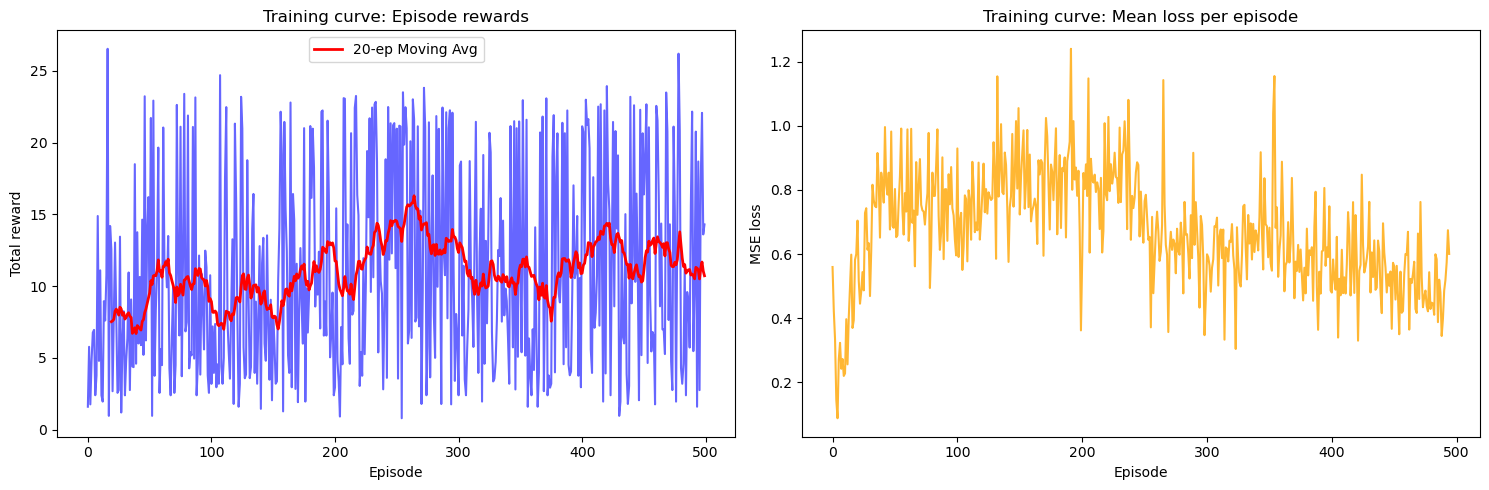

In [ ]:
plot_training_curves(dqn_rewards, dqn_losses)

#### 2.6 - Evaluate the DQN model

In [16]:
dqn_results = evaluate_agent(trained_dqn_agent, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [07:12<00:00,  8.66s/it]


Seed 3 | Mean Reward: 16.84 +/- 6.46



Evaluating Seed 33: 100%|██████████| 50/50 [06:19<00:00,  7.60s/it]


Seed 33 | Mean Reward: 16.29 +/- 6.06



Evaluating Seed 333: 100%|██████████| 50/50 [05:55<00:00,  7.12s/it]

Seed 333 | Mean Reward: 17.00 +/- 6.13



#### 2.7 - Record a rollout

Recording rollout
Episode finished after 30 steps.


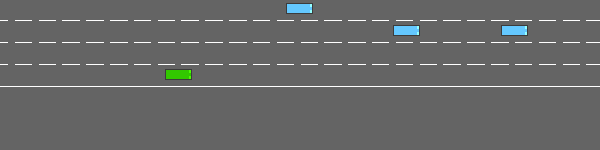

In [ ]:
record_display_rollout(agent=trained_dqn_agent, seed=3, name_dir=".", name_gif="dqn_agent_rollout")

### 3. Implement a DDQN: DQN with double Q-learning

This DDQN agent is very similar to the DQN one. The only change I made lies in the update function. More particularly, in the way the target used in the loss function is computed: here, we first find the actions that maximize the Q-values in the next state in the main network, then we update using the Q-values in the next state for these actions in the target network. The goal is to decouple selection of the actions from evaluation of the Q-values to fix the overestimation bias.

This is an adaptation of the double Q-learning method mentioned in class, where we have two separate networks Q1 or Q2, and update one of them randomly at each step. Instead, we use the main and the target networks that we already have: the main network acts like Q1 and the target network acts like Q2, but we always pick the action using the main network and evaluate it using the target one.

This idea comes from the double Q-learning adaptation to DQN proposed by van Hasselt et al [https://arxiv.org/abs/1509.06461].

#### 3.1 - Agent

In [16]:
class CustomDDQNAgent:
    def __init__(self, action_space, observation_space):
        self.action_space = action_space
        self.observation_space = observation_space
        # Hyperparameters
        self.learning_rate = 5e-4
        self.gamma = 0.8 # Discount factor
        self.batch_size = 32
        self.buffer_capacity = 15000 # Memory size
        self.update_target_every = 50
        # Exploration parameters
        self.epsilon_start = 0.9 # Start here because it will change: we will decrease it
        self.epsilon_min = 0.05
        self.decrease_epsilon_factor = 2000
        self.epsilon = self.epsilon_start
        
        # Initializiation
        self.buffer = ReplayBuffer(self.buffer_capacity)
        obs_shape = self.observation_space.shape
        n_actions = self.action_space.n
        hidden_size = 128 
        
        # Define the Deep Q-network and the target network
        self.q_net = Net(obs_shape, hidden_size, n_actions)
        self.target_net = Net(obs_shape, hidden_size, n_actions)
        # We ensure that they have the same weight at the beginning
        self.target_net.load_state_dict(self.q_net.state_dict()) 
        
        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)
        self.loss_function = nn.MSELoss()
        
        self.n_steps = 0 # Total steps
        self.n_eps = 0 # Total episodes

    def get_q(self, state):
        """Get the Q values of the given state by using the network"""
        # Convert numpy state to PyTorch tensor
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            output = self.q_net.forward(state_tensor)
        return output.numpy()[0]
    
    def get_action(self, state):
        """Chooses an action using the epsilon-greedyfication"""
        if np.random.rand() < self.epsilon:
            return self.action_space.sample()
        else:
            q_values = self.get_q(state)
            return np.argmax(q_values)
            
    def decrease_epsilon(self):
        """Gradually reduces the chance of taking random actions over time"""
        self.epsilon = self.epsilon_min + (self.epsilon_start - self.epsilon_min) * (
                        np.exp(-1. * self.n_eps / self.decrease_epsilon_factor) )
        
    def update(self, state, action, reward, terminated, next_state):
        """Stores the transition and performs one step of gradient descent"""
        
        # Store the transition in the Replay Buffer
        # Convert the inputs to tensors
        self.buffer.push(
            torch.tensor(state, dtype=torch.float32).unsqueeze(0), 
            torch.tensor([[action]], dtype=torch.int64), 
            torch.tensor([reward], dtype=torch.float32), 
            torch.tensor([terminated], dtype=torch.int64), 
            torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)
        )
        # Check that we have enough data to train
        if len(self.buffer) < self.batch_size:
            return np.inf 

        # Dample a batch
        transitions = self.buffer.sample(self.batch_size)

        # Transpose the batch
        state_batch, action_batch, reward_batch, terminated_batch, next_state_batch = tuple(
            [torch.cat(data) for data in zip(*transitions)]
        )

        # Compute current Q-values
        q_values = self.q_net(state_batch).gather(1, action_batch)

        # Compute target Q-values (Bellman equation)
        with torch.no_grad():
            # Here lies the difference with the "simple" DQN: first, we find the actions
            # that maximize the Q-values in the next state in the main network ; then,
            # we update using the Q-values in the next state for these actions in the target network
            next_state_indices_main = self.q_net(next_state_batch).argmax(dim=1, keepdim=True)
            next_state_values_target = self.target_net(next_state_batch).gather(1, next_state_indices_main).squeeze(1)
            # Then, same as in DQN
            next_state_values_target = next_state_values_target * (1 - terminated_batch)
            targets = reward_batch + (self.gamma * next_state_values_target)

        # Compute loss and backpropagate
        loss = self.loss_function(q_values, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network if necessary
        if self.n_steps % self.update_target_every == 0: 
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        # Update epsilon
        self.decrease_epsilon()
        self.n_steps += 1
        if terminated: 
            self.n_eps += 1
        return loss.item()

#### 3.2 Train the DDQN model

In [18]:
N_EPISODES = 500
env = make_env()
ddqn_agent = CustomDDQNAgent(env.action_space, env.observation_space)
trained_ddqn_agent, ddqn_rewards, ddqn_losses = train_agent(ddqn_agent, env, n_episodes=N_EPISODES)

Training agent: 100%|██████████| 500/500 [1:00:54<00:00,  7.31s/it]


Save the model

In [19]:
file_path = "trained_ddqn_highway.pth"
torch.save(trained_ddqn_agent.q_net.state_dict(), file_path)

#### 3.3 Evaluate the DDQN model

In [20]:
ddqn_results = evaluate_agent(trained_ddqn_agent, num_episodes=50)

Starting evaluation: 50 episodes per seed.


Evaluating Seed 3: 100%|██████████| 50/50 [13:33<00:00, 16.27s/it]


Seed 3 | Mean Reward: 20.22 +/- 2.47



Evaluating Seed 33: 100%|██████████| 50/50 [13:29<00:00, 16.19s/it]


Seed 33 | Mean Reward: 19.69 +/- 3.84



Evaluating Seed 333: 100%|██████████| 50/50 [13:03<00:00, 15.68s/it]

Seed 333 | Mean Reward: 19.64 +/- 4.06



#### 3.4 Plot the training curves

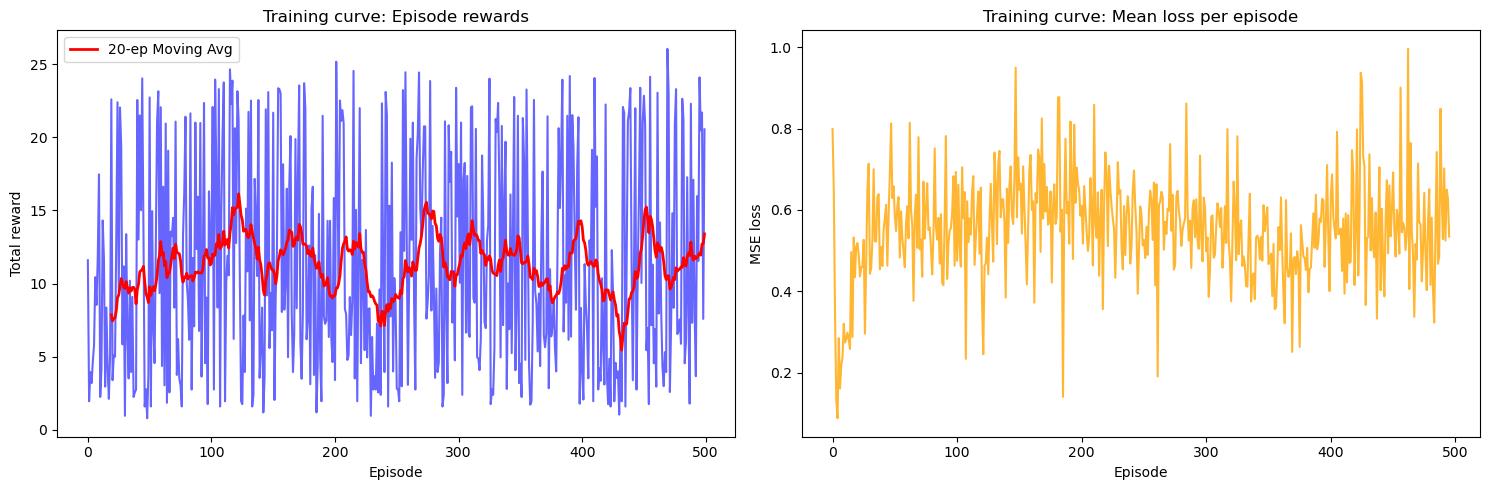

In [25]:
plot_training_curves(ddqn_rewards, ddqn_losses)

#### 3.5 Record rollout

Recording rollout
Episode finished after 30 steps.


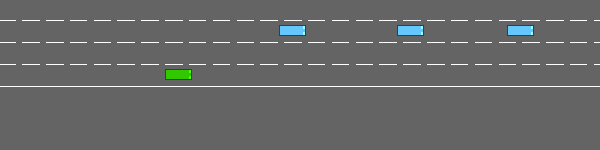

In [24]:
record_display_rollout(agent=trained_ddqn_agent, seed=33, name_dir=".", name_gif="ddqn_agent_rollout")